# Parser debug plots

Quick visual check that the field-profile parsers and the layer segmentation behave. `weac.parser.plotting.plot_force_penetration_parser` runs a parser and lays out four depth-aligned panels:

1. **Penetration force** vs recorded depth.
2. **Sample density** vs recorded depth (derived via the chosen model).
3. **Sample density** vs slope-normal depth. SnowScope records plumb depth, so this panel compresses by `cos(phi)`. The SnowMicroPen is driven normal to the slope, so its recorded depth is already slope-normal and this panel matches panels 1-2.
4. **Segmented layers** (`bin` or `gradient`) vs slope-normal depth, with the slope-normal density faintly overlaid so you can eyeball whether the layering tracked the signal.

Panels 3-4 use WEAC's slope-normal `Layer.h`. The same plotting code serves both parsers because their profiles share the `depth_mm` / `penetration_resistance_kPa` / `density_kg_m3` fields.

Both sample profiles in `demo/data/` are a **co-located pair** from Weissfluhjoch on 2025-12-15: the SnowMicroPen `.PNT` and the SnowScope `.csv` were taken the same morning ~4 m apart, so their profiles are directly comparable.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np

from weac.parser import SMPParser, SnowPilotParser, SnowScopeParser
from weac.parser.plotting import (
    plot_force_penetration_layers,
    plot_force_penetration_parser,
    plot_snowscope_penetration_parser,
)

DATA = Path("data") if Path("data").exists() else Path("demo") / "data"
PNT = DATA / "S36N2470.PNT"
CSV = DATA / "Profile671_SN00353.csv"
PNT, CSV

(PosixPath('data/S36N2470.PNT'), PosixPath('data/Profile671_SN00353.csv'))

# SnowMicroPen (`.PNT`)

`CR2020` (Calonne & Richter 2020) is the most robust parameterization on this file; `P2015` / `K2020b` can dip negative in noisy windows. Surface and ground are auto-detected at construction.

In [2]:
smp = SMPParser(str(PNT), density_method="CR2020")
smp_profile = smp.extract_profile()
print("coordinates :", smp_profile.coordinates)
print("samples     :", smp_profile.depth_mm.size)
print(
    "depth (mm)  : %.1f -> %.1f" % (smp_profile.depth_mm[0], smp_profile.depth_mm[-1])
)
print(
    "force (kPa) : %.1f - %.1f"
    % (
        smp_profile.penetration_resistance_kPa.min(),
        smp_profile.penetration_resistance_kPa.max(),
    )
)
print(
    "density     : %.1f - %.1f kg/m3"
    % (smp_profile.density_kg_m3.min(), smp_profile.density_kg_m3.max())
)

coordinates : (46.82966613769531, 9.809202194213867)
samples     : 1344
depth (mm)  : 0.0 -> 671.5
force (kPa) : 4.1 - 1132.5
density     : 144.5 - 463.3 kg/m3


## Bin segmentation (fixed thickness)

One call debug view. `bin` groups samples into ~`layer_thickness_mm` slabs (here 20 mm).

SMP bin 20 mm -> 34 layers


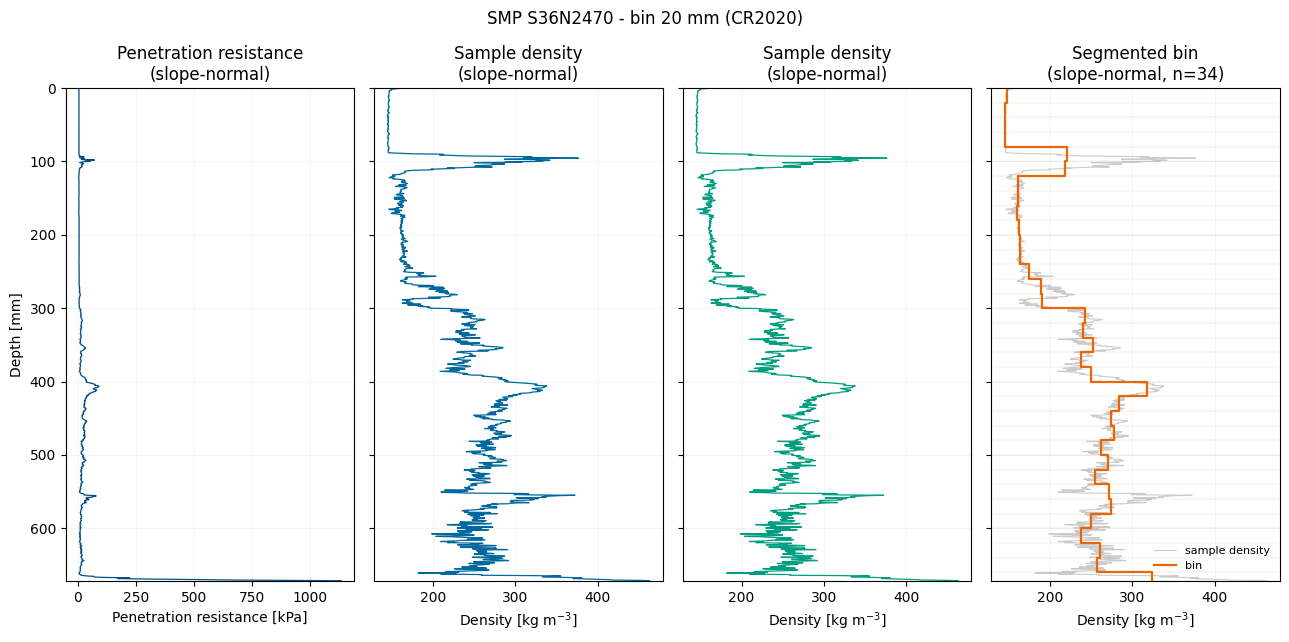

In [3]:
smp_bin, _ = smp.extract_layers(method="bin", layer_thickness_mm=20.0)
print(f"SMP bin 20 mm -> {len(smp_bin)} layers")
fig = plot_force_penetration_parser(
    smp,
    method="bin",
    layer_thickness_mm=20.0,
    title="SMP S36N2470 - bin 20 mm (CR2020)",
    show=False,
)

## Gradient segmentation

`gradient` cuts a new layer wherever `|drho/dz|` over a fixed 2.5 mm span exceeds the threshold (kg/m3/mm), so ramps become a staircase and quiet stretches collapse into one layer.

SMP gradient T=12 -> 82 layers


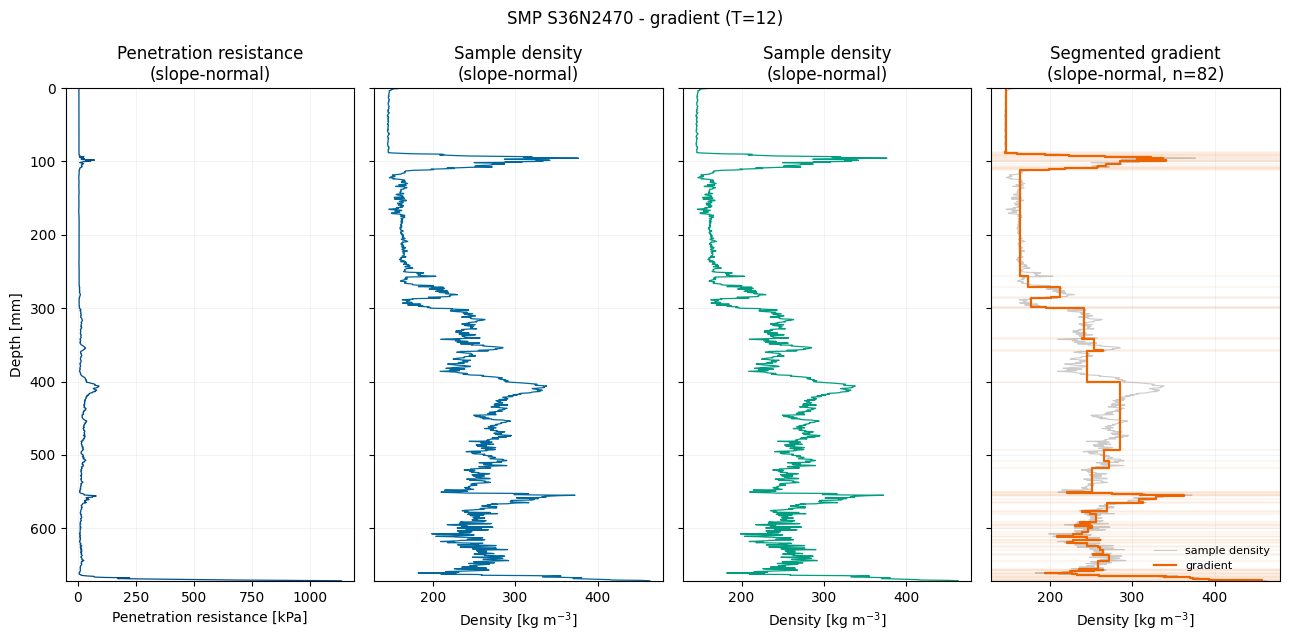

In [4]:
smp_grad, _ = smp.extract_layers(method="gradient", gradient_threshold=12.0)
print(f"SMP gradient T=12 -> {len(smp_grad)} layers")
fig = plot_force_penetration_parser(
    smp,
    method="gradient",
    gradient_threshold=12.0,
    title="SMP S36N2470 - gradient (T=12)",
    show=False,
)

## Depths are already slope-normal

The SnowMicroPen is pushed normal to the slope, so `depth_mm` is used directly as `Layer.h`. There is no `slope_angle_deg` on `SMPParser`. Plumb profiles (SnowScope, SnowPilot) still scale thickness by `cos(phi)`; that demo is in the SnowScope section below.

In [5]:
recorded_mm = float(
    np.diff(smp_profile.depth_mm).sum() + np.diff(smp_profile.depth_mm)[-1]
)
print(
    f"SMP bin thickness {sum(layer.h for layer in smp_bin):.1f} mm "
    f"matches recorded slope-normal depth {recorded_mm:.1f} mm"
)

SMP bin thickness 672.0 mm matches recorded slope-normal depth 672.0 mm


## Force offset (drift correction)

The SMP force signal carries a small baseline drift. Passing `apply_drift_correction=True` at construction calls snowmicropyn's `subtract_force_offset()`, which subtracts a near-constant offset (~3 kPa here) from the whole profile. It barely moves the strong sub-surface signal but noticeably lifts the weak near-surface force off the baseline, so it mainly matters when the low-force detail (and the density derived from it) is of interest. Below we overlay the raw and offset-corrected force on the same depth axis.

Surface at:  43.0
median subtracted offset: 3.35 kPa


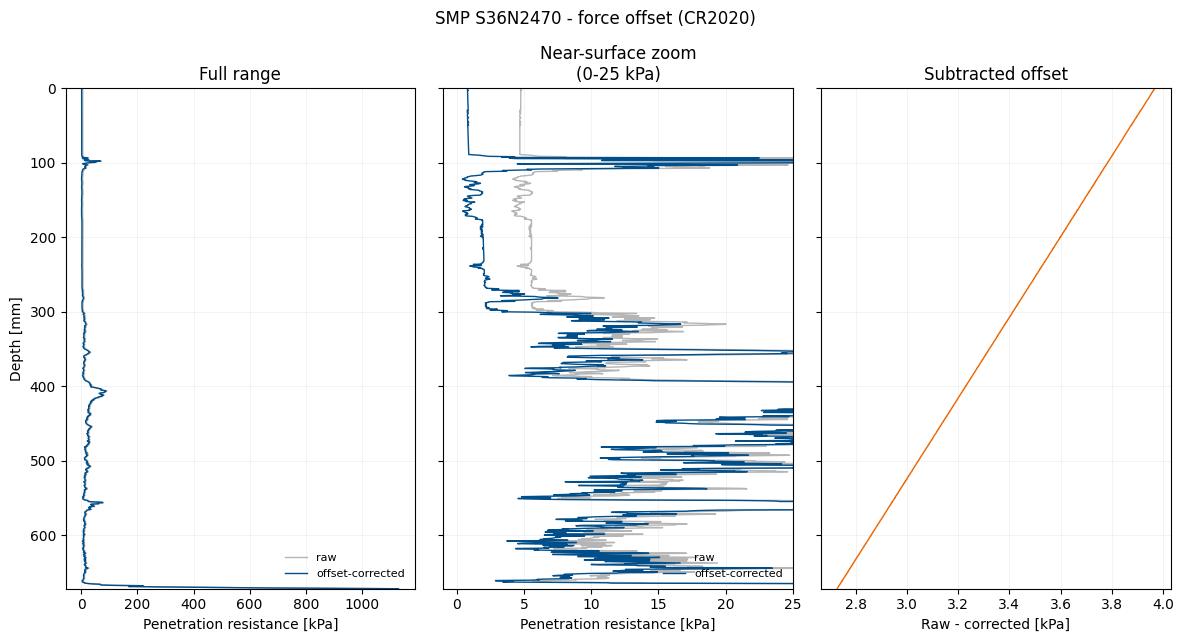

median raw - corrected density: 7.1 kg/m3; max |delta|: 100.6 kg/m3


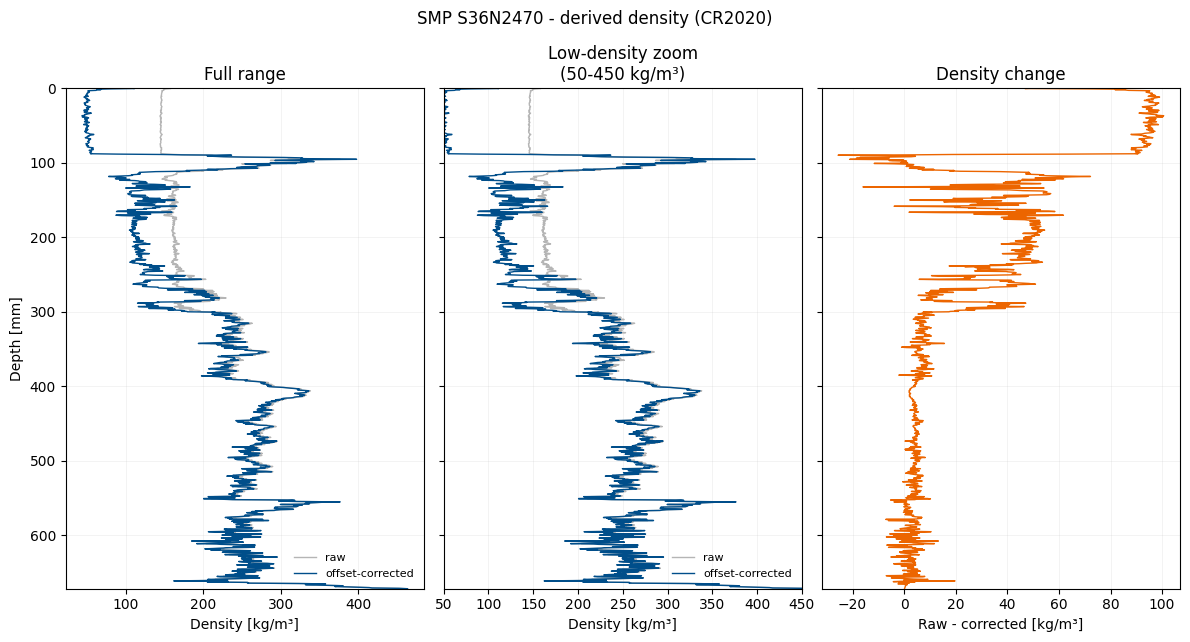

In [6]:
import matplotlib.pyplot as plt

smp_raw = SMPParser(str(PNT), density_method="CR2020", apply_drift_correction=False)
smp_corr = SMPParser(str(PNT), density_method="CR2020", apply_drift_correction=True)
prof_raw = smp_raw.extract_profile()
prof_corr = smp_corr.extract_profile()

offset = float(
    np.nanmedian(
        prof_raw.penetration_resistance_kPa - prof_corr.penetration_resistance_kPa
    )
)
print(f"median subtracted offset: {offset:.2f} kPa")

fig, (ax_full, ax_zoom, ax_diff) = plt.subplots(1, 3, figsize=(12, 6.5), sharey=True)

for ax in (ax_full, ax_zoom):
    ax.plot(
        prof_raw.penetration_resistance_kPa,
        prof_raw.depth_mm,
        color="#B5B5B5",
        lw=1.0,
        label="raw",
    )
    ax.plot(
        prof_corr.penetration_resistance_kPa,
        prof_corr.depth_mm,
        color="#004E8A",
        lw=1.0,
        label="offset-corrected",
    )
    ax.set_xlabel("Penetration resistance [kPa]")

ax_full.set_ylabel("Depth [mm]")
ax_full.set_title("Full range")
ax_full.legend(loc="lower right", fontsize=8, frameon=False)

# Zoom the weak-signal window where a ~3 kPa offset actually shows.
ax_zoom.set_xlim(-1.0, 25.0)
ax_zoom.set_title("Near-surface zoom\n(0-25 kPa)")
ax_zoom.legend(loc="lower right", fontsize=8, frameon=False)

ax_diff.plot(
    prof_raw.penetration_resistance_kPa - prof_corr.penetration_resistance_kPa,
    prof_raw.depth_mm,
    color="#EC6500",
    lw=1.0,
)
ax_diff.set_xlabel("Raw - corrected [kPa]")
ax_diff.set_title("Subtracted offset")

ax_full.set_ylim(float(np.nanmax(prof_raw.depth_mm)), float(prof_raw.depth_mm[0]))
for ax in (ax_full, ax_zoom, ax_diff):
    ax.grid(True, alpha=0.25, lw=0.4)
fig.suptitle("SMP S36N2470 - force offset (CR2020)")
fig.tight_layout()
plt.show()

density_delta = prof_raw.density_kg_m3 - prof_corr.density_kg_m3
print(
    f"median raw - corrected density: {float(np.nanmedian(density_delta)):.1f} kg/m3; "
    f"max |delta|: {float(np.nanmax(np.abs(density_delta))):.1f} kg/m3"
)

fig, (ax_full, ax_zoom, ax_diff) = plt.subplots(1, 3, figsize=(12, 6.5), sharey=True)

for ax in (ax_full, ax_zoom):
    ax.plot(
        prof_raw.density_kg_m3, prof_raw.depth_mm, color="#B5B5B5", lw=1.0, label="raw"
    )
    ax.plot(
        prof_corr.density_kg_m3,
        prof_corr.depth_mm,
        color="#004E8A",
        lw=1.0,
        label="offset-corrected",
    )
    ax.set_xlabel("Density [kg/m³]")

ax_full.set_ylabel("Depth [mm]")
ax_full.set_title("Full range")
ax_full.legend(loc="lower right", fontsize=8, frameon=False)

ax_zoom.set_xlim(50.0, 450.0)
ax_zoom.set_title("Low-density zoom\n(50-450 kg/m³)")
ax_zoom.legend(loc="lower right", fontsize=8, frameon=False)

ax_diff.plot(density_delta, prof_raw.depth_mm, color="#EC6500", lw=1.0)
ax_diff.set_xlabel("Raw - corrected [kg/m³]")
ax_diff.set_title("Density change")

ax_full.set_ylim(float(np.nanmax(prof_raw.depth_mm)), float(prof_raw.depth_mm[0]))
for ax in (ax_full, ax_zoom, ax_diff):
    ax.grid(True, alpha=0.25, lw=0.4)
fig.suptitle("SMP S36N2470 - derived density (CR2020)")
fig.tight_layout()
plt.show()

## Surface detection

`surface_method` picks the snow-surface marker before ground detection and the Löwe / CR2020 parameterization. `"snowmicropyn"` is `Profile.detect_surface()`. `"knappe"` is Knappe surface detection: a 1 mm moving linear regression, Hanning-smoothed, thresholded at 5× the standard deviation of the quietest 20 mm inside the first 100 mm (air above the snow). A crossing counts only when the next 1 mm stays above that threshold, so a single noise spike is dropped.

A manual `surface_mm` still overrides either method. The two profiles below both use CR2020. Depth is millimetres along the probe, counted from the top of the recording, so the curves share one axis and each one starts at its own surface.

snowmicropyn surface: 43.0 mm
Knappe surface:       132.5 mm
surface offset:       89.5 mm


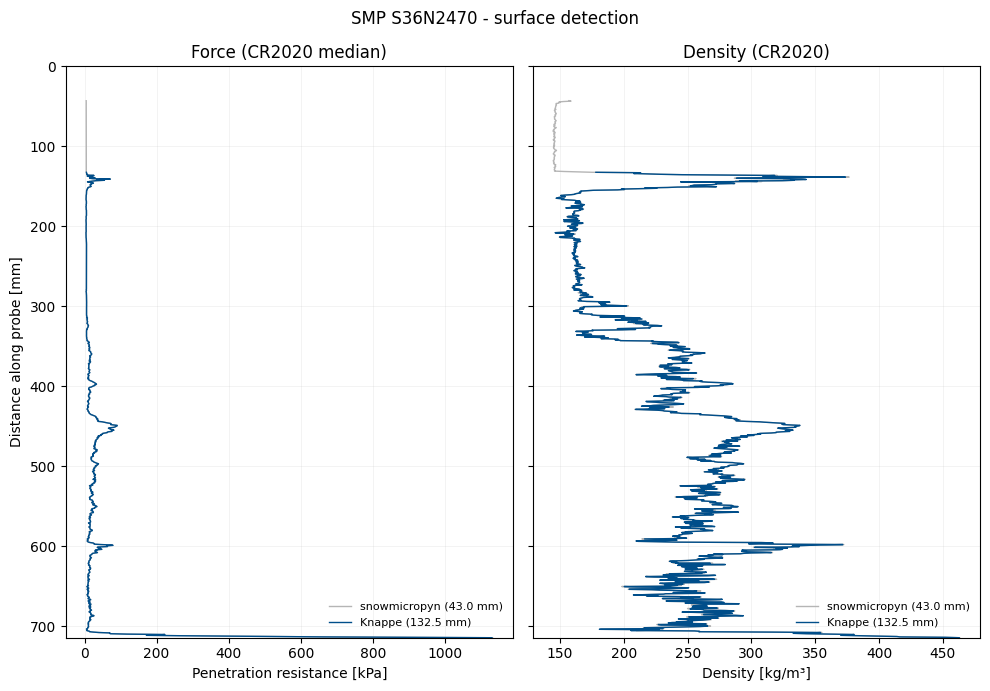

In [7]:
import matplotlib.pyplot as plt

smp_lib = SMPParser(str(PNT), density_method="CR2020", surface_method="snowmicropyn")
smp_knappe = SMPParser(str(PNT), density_method="CR2020", surface_method="knappe")
prof_lib = smp_lib.extract_profile()
prof_knappe = smp_knappe.extract_profile()

surface_lib = float(smp_lib.loaded_profile.surface)
surface_knappe = float(smp_knappe.loaded_profile.surface)
print(f"snowmicropyn surface: {surface_lib:.1f} mm")
print(f"Knappe surface:       {surface_knappe:.1f} mm")
print(f"surface offset:       {surface_knappe - surface_lib:.1f} mm")

# extract_profile() reports depth below the chosen surface. Add the marker
# back so both parameterizations sit on the probe's distance axis.
depth_lib = surface_lib + prof_lib.depth_mm
depth_knappe = surface_knappe + prof_knappe.depth_mm

fig, (ax_force, ax_density) = plt.subplots(1, 2, figsize=(10, 7), sharey=True)

ax_force.plot(
    prof_lib.penetration_resistance_kPa,
    depth_lib,
    color="#B5B5B5",
    lw=1.0,
    label=f"snowmicropyn ({surface_lib:.1f} mm)",
)
ax_force.plot(
    prof_knappe.penetration_resistance_kPa,
    depth_knappe,
    color="#004E8A",
    lw=1.0,
    label=f"Knappe ({surface_knappe:.1f} mm)",
)
ax_force.set_xlabel("Penetration resistance [kPa]")
ax_force.set_ylabel("Distance along probe [mm]")
ax_force.set_title("Force (CR2020 median)")
ax_force.legend(loc="lower right", fontsize=8, frameon=False)

ax_density.plot(
    prof_lib.density_kg_m3,
    depth_lib,
    color="#B5B5B5",
    lw=1.0,
    label=f"snowmicropyn ({surface_lib:.1f} mm)",
)
ax_density.plot(
    prof_knappe.density_kg_m3,
    depth_knappe,
    color="#004E8A",
    lw=1.0,
    label=f"Knappe ({surface_knappe:.1f} mm)",
)
ax_density.set_xlabel("Density [kg/m\u00b3]")
ax_density.set_title("Density (CR2020)")
ax_density.legend(loc="lower right", fontsize=8, frameon=False)

bottom = max(float(np.nanmax(depth_lib)), float(np.nanmax(depth_knappe)))
ax_force.set_ylim(bottom, 0.0)
for ax in (ax_force, ax_density):
    ax.grid(True, alpha=0.25, lw=0.4)
fig.suptitle("SMP S36N2470 - surface detection")
fig.tight_layout()
plt.show()

# SnowScope (`.csv`)

The SnowScope parser reads penetration hardness (kPa) and derives density from a semilog model `D = a ln(F) + b` (default preset `HAGENMULLER2018`). Pass `semilog_slope` / `semilog_intercept` on the parser, on `extract_profile` / `extract_layers`, or on `plot_snowscope_penetration_parser` (or `plot_force_penetration_parser`) for site-specific calibrations (profile label `CUSTOM`). SnowScope profiles expose `penetration_resistance_kPa` like SMP, so the same four-panel plot helpers apply. This CSV is the co-located partner of the SMP profile above.


In [8]:
scope = SnowScopeParser(str(CSV))
# Illustrative alternate calibration (custom semilog, not a shipped preset).
DEMO_SEMILOG_SLOPE = 50.0
DEMO_SEMILOG_INTERCEPT = 100.0
scope_custom = SnowScopeParser(
    str(CSV),
    semilog_slope=DEMO_SEMILOG_SLOPE,
    semilog_intercept=DEMO_SEMILOG_INTERCEPT,
)
scope_profile = scope.extract_profile()
scope_profile_custom = scope_custom.extract_profile()
scope_profile_oneoff = scope.extract_profile(
    semilog_slope=55.0,
    semilog_intercept=40.0,
)

print("samples     :", scope_profile.depth_mm.size)
print(
    "depth (mm)  : %.1f -> %.1f"
    % (scope_profile.depth_mm[0], scope_profile.depth_mm[-1])
)
print(
    "penetration resistance (kPa) : %.1f - %.1f"
    % (
        scope_profile.penetration_resistance_kPa.min(),
        scope_profile.penetration_resistance_kPa.max(),
    )
)
print(
    "density (HAGENMULLER2018) : %.1f - %.1f kg/m3"
    % (scope_profile.density_kg_m3.min(), scope_profile.density_kg_m3.max())
)
print("custom label  :", scope_profile_custom.density_method)
print(
    "custom density: %.0f - %.0f kg/m3"
    % (
        scope_profile_custom.density_kg_m3.min(),
        scope_profile_custom.density_kg_m3.max(),
    )
)
print("one-off label :", scope_profile_oneoff.density_method)
print(
    "one-off density: %.0f - %.0f kg/m3"
    % (
        scope_profile_oneoff.density_kg_m3.min(),
        scope_profile_oneoff.density_kg_m3.max(),
    )
)

samples     : 690
depth (mm)  : 1.0 -> 690.0
penetration resistance (kPa) : 1.4 - 379.7
density (HAGENMULLER2018) : 47.5 - 445.6 kg/m3
custom label  : CUSTOM
custom density: 118 - 397 kg/m3
one-off label : CUSTOM
one-off density: 60 - 367 kg/m3


## Bin segmentation

SnowScope bin 20 mm -> 35 layers


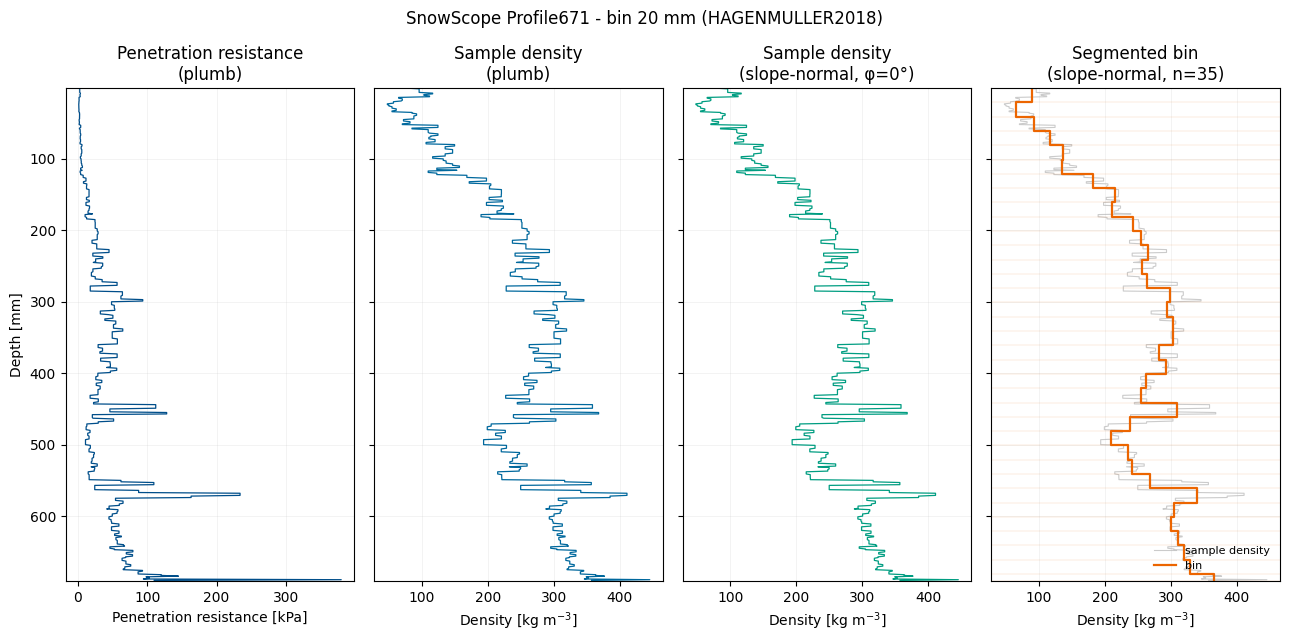

In [9]:
scope_bin, _ = scope.extract_layers(method="bin", layer_thickness_mm=20.0)
print(f"SnowScope bin 20 mm -> {len(scope_bin)} layers")
fig = plot_snowscope_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    title="SnowScope Profile671 - bin 20 mm (HAGENMULLER2018)",
    show=False,
)

## Slope-normal effect

SnowScope depths are plumb. Passing a non-zero `slope_angle_deg` scales `Layer.h` (and the slope-normal panels) by `cos(phi)`. Panels 1-2 stay plumb; panels 3-4 compress, and the staircase still tracks the slope-normal density. The layer *count* is unchanged — only the thicknesses scale.

SnowScope bin 20 mm @ 35 deg -> 35 layers


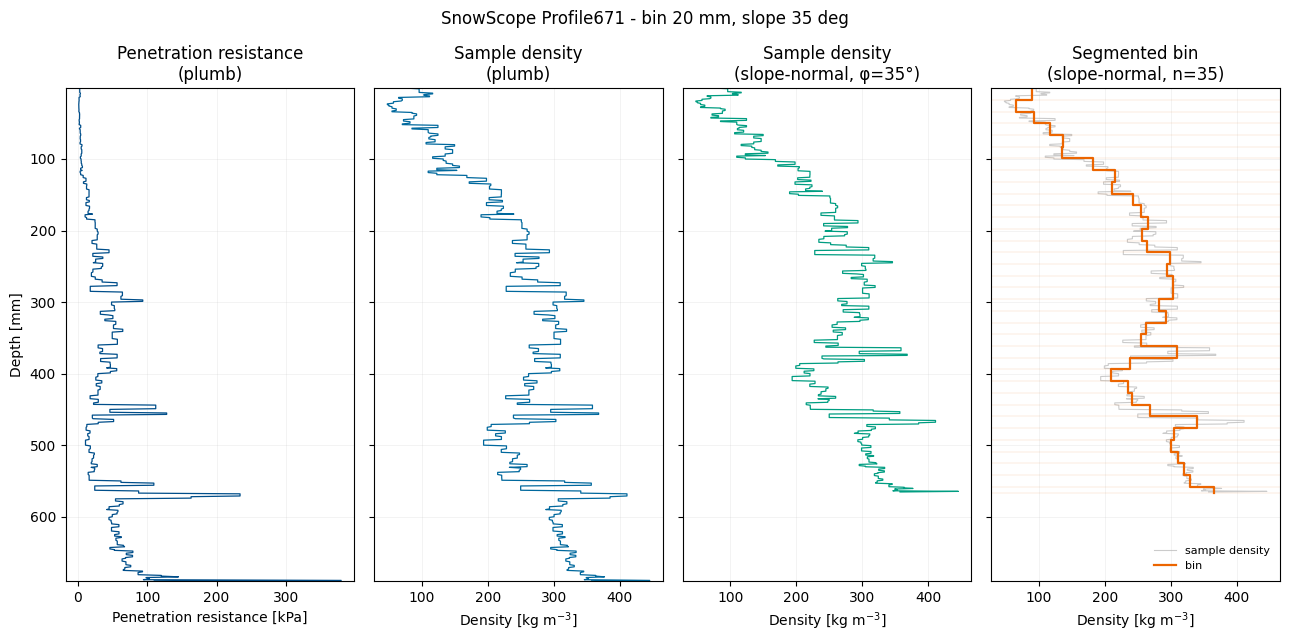

In [10]:
scope_slope, _ = scope.extract_layers(
    slope_angle_deg=35.0, method="bin", layer_thickness_mm=20.0
)
print(f"SnowScope bin 20 mm @ 35 deg -> {len(scope_slope)} layers")
fig = plot_snowscope_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    slope_angle_deg=35.0,
    title="SnowScope Profile671 - bin 20 mm, slope 35 deg",
    show=False,
)

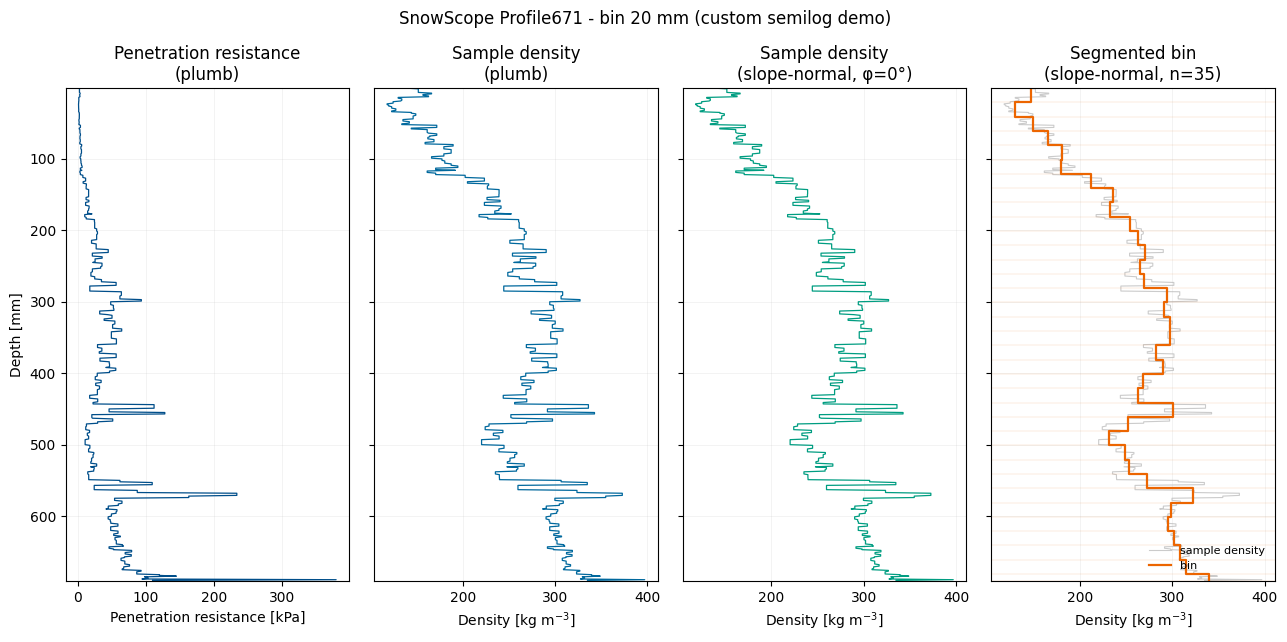

In [11]:
# Same panels with custom semilog on the plot call (constructor default unchanged).
fig = plot_force_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    semilog_slope=DEMO_SEMILOG_SLOPE,
    semilog_intercept=DEMO_SEMILOG_INTERCEPT,
    title="SnowScope Profile671 - bin 20 mm (custom semilog demo)",
    show=False,
)

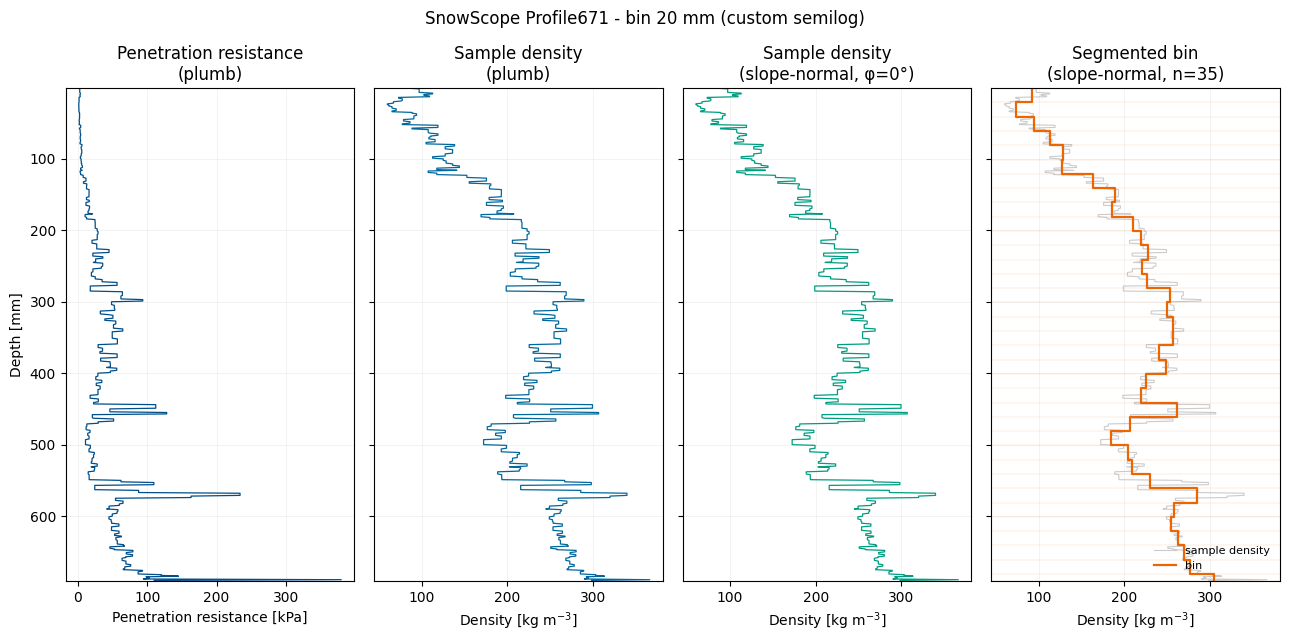

In [12]:
fig = plot_snowscope_penetration_parser(
    scope,
    method="bin",
    layer_thickness_mm=20.0,
    semilog_slope=55.0,
    semilog_intercept=40.0,
    title="SnowScope Profile671 - bin 20 mm (custom semilog)",
    show=False,
)

## Gradient segmentation

SnowScope gradient T=12 -> 123 layers


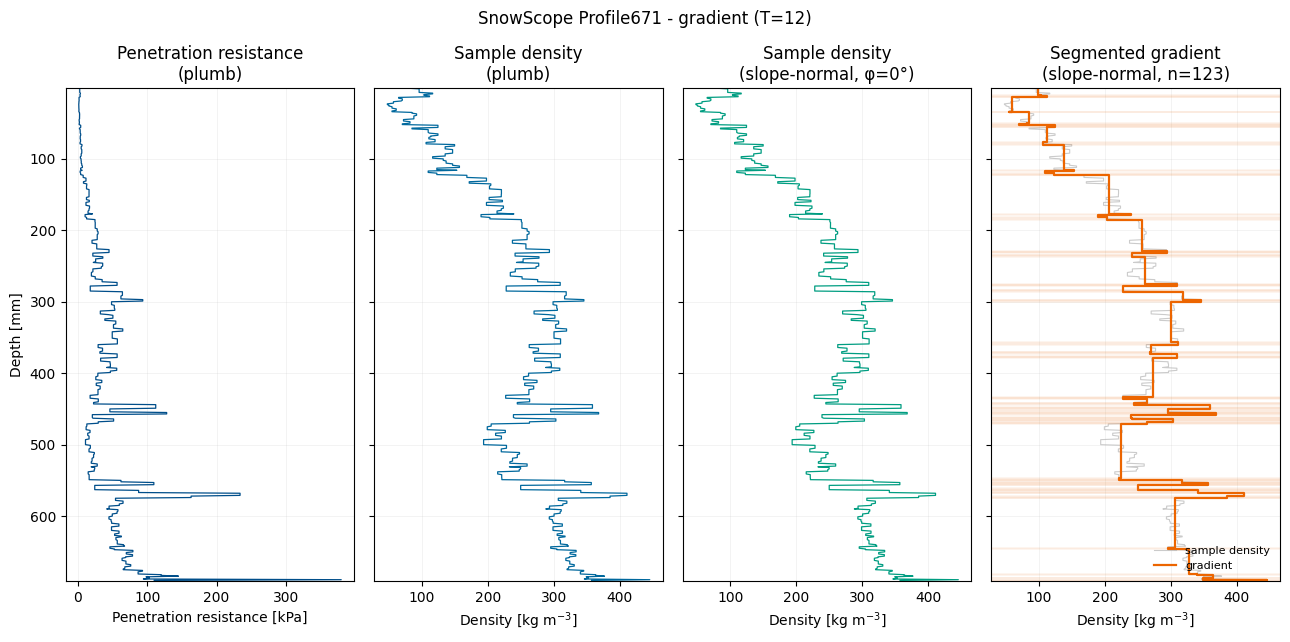

In [13]:
scope_grad, _ = scope.extract_layers(method="gradient", gradient_threshold=12.0)
print(f"SnowScope gradient T=12 -> {len(scope_grad)} layers")
fig = plot_force_penetration_parser(
    scope,
    method="gradient",
    gradient_threshold=12.0,
    title="SnowScope Profile671 - gradient (T=12)",
    show=False,
)

## Gradient threshold sensitivity

In `gradient` mode, `gradient_threshold` is the cut threshold **T** (kg/m³ per mm) on |dρ/dz| over a fixed **2.5 mm** span. **Lower T** → more samples exceed the threshold → **more, thinner layers**. **Higher T** → only sharp density steps become cuts → **fewer, thicker layers**. The counts below should drop sharply as T increases; the overlaid staircases show the same profile segmented two ways.


SMP gradient T=4 -> 347 layers
SMP gradient T=20 -> 26 layers
SnowScope gradient T=4 -> 381 layers
SnowScope gradient T=20 -> 52 layers


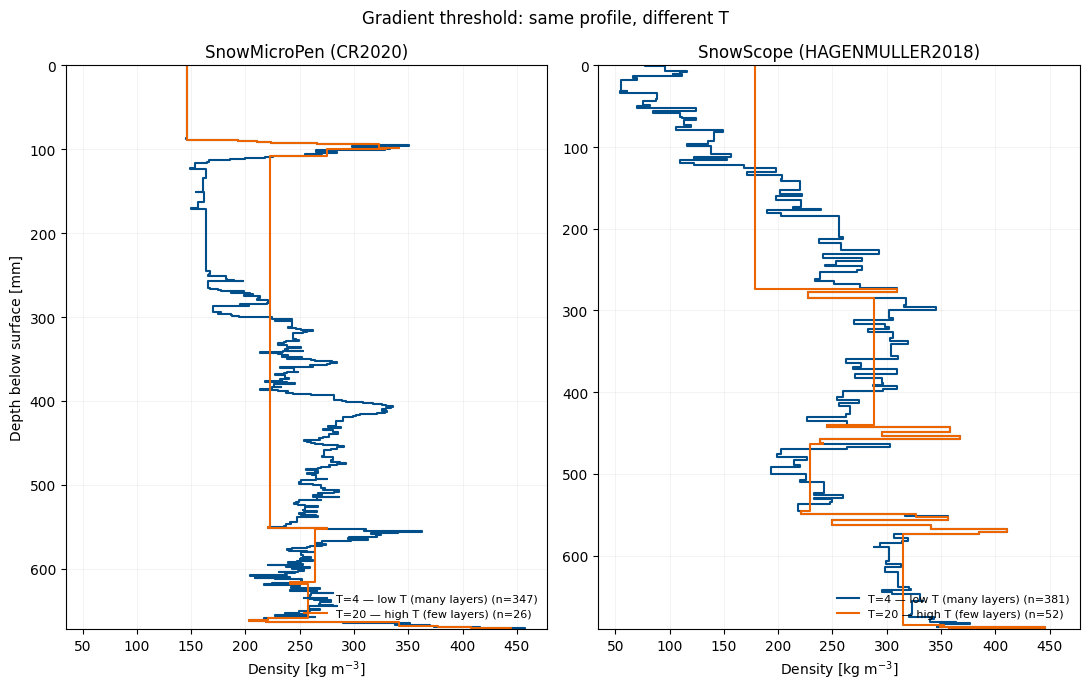

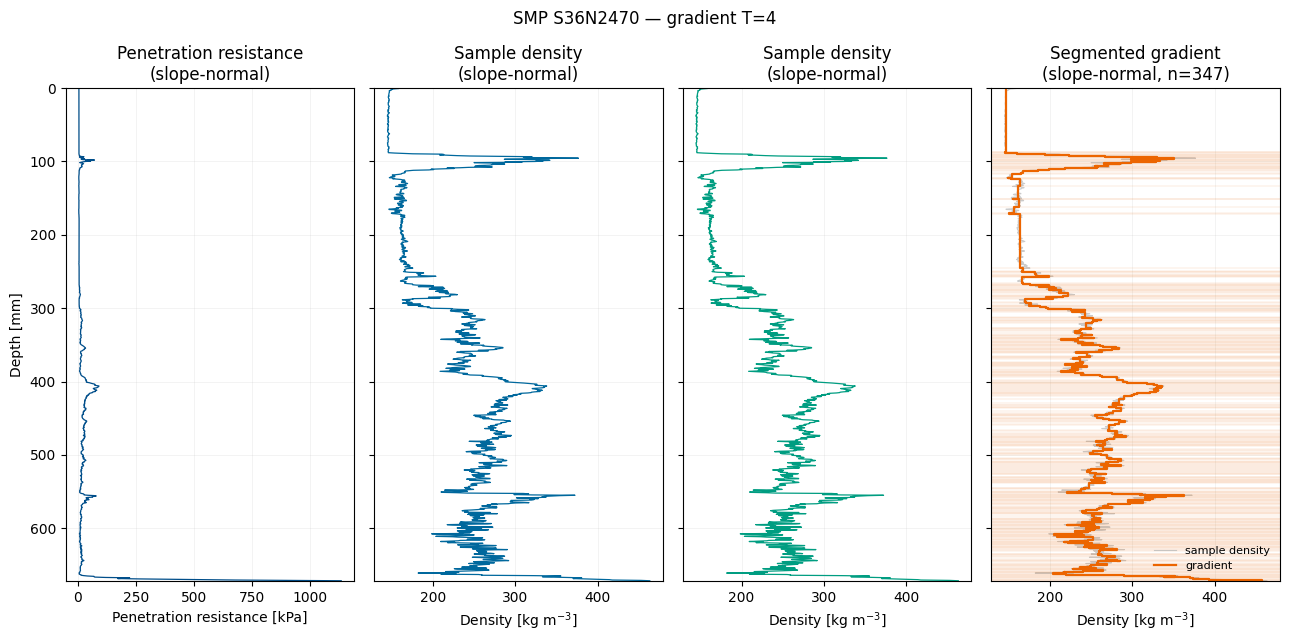

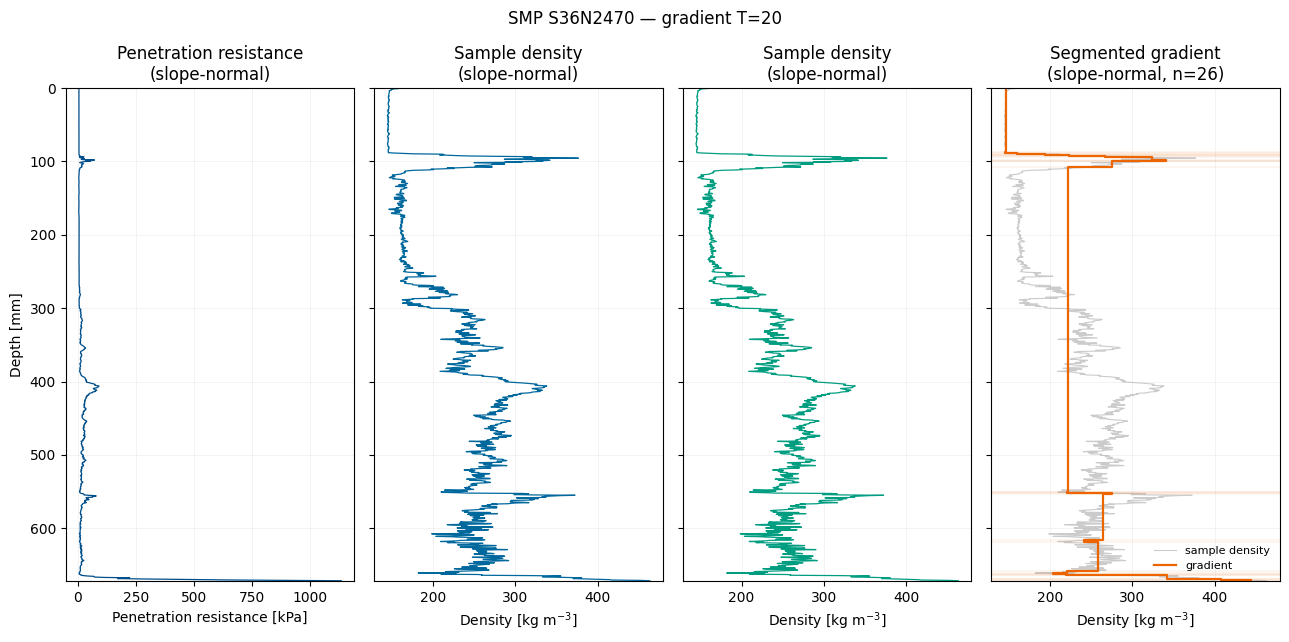

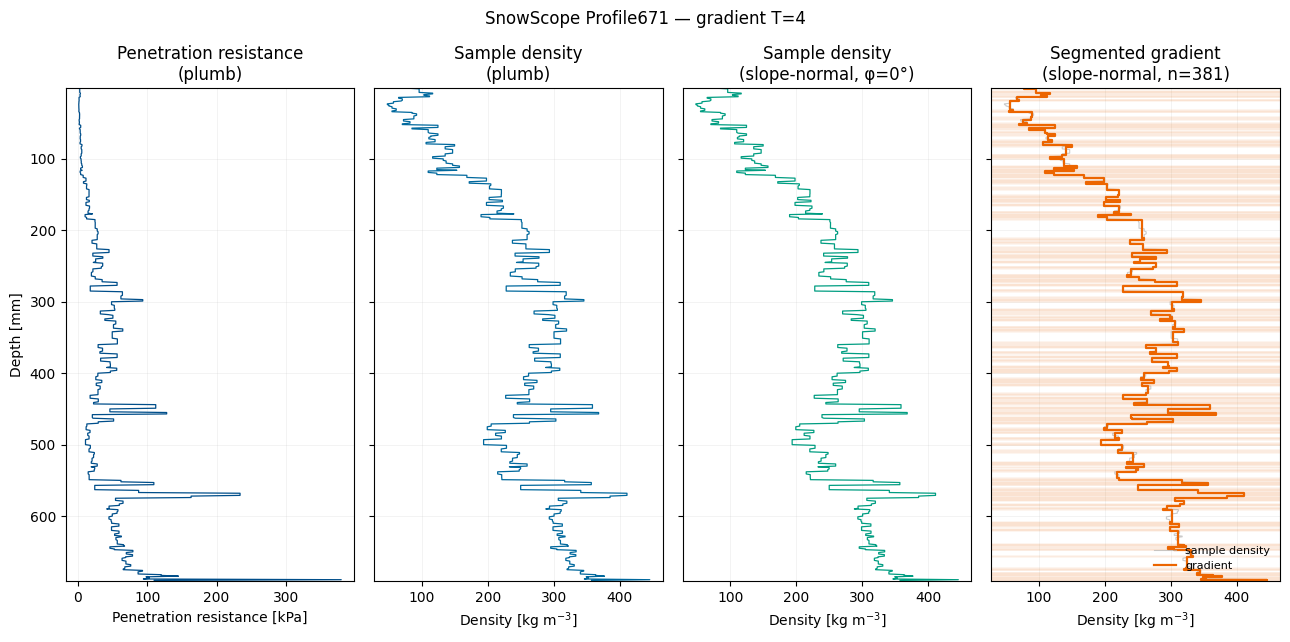

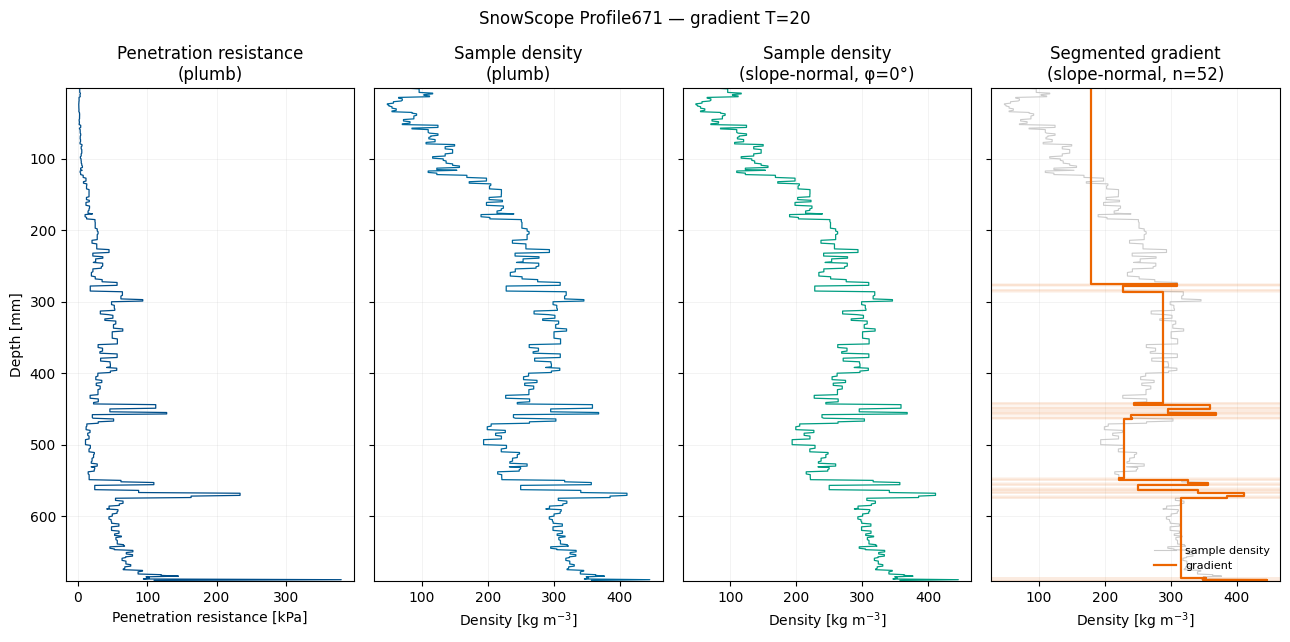

In [14]:
import matplotlib.pyplot as plt

# Deliberately far apart so layer counts and staircases diverge clearly.
GRADIENT_THRESHOLD_LOW = 4.0
GRADIENT_THRESHOLD_HIGH = 20.0


def staircase_from_surface(layers):
    """Density-vs-depth staircase anchored at the surface (depth 0, downward)."""
    h = np.array([layer.h for layer in layers], float)
    rho = np.repeat([layer.rho for layer in layers], 2)
    bottoms = np.cumsum(h)
    tops = np.concatenate(([0.0], bottoms[:-1]))
    depth = np.empty(rho.size)
    depth[0::2] = tops
    depth[1::2] = bottoms
    return rho, depth


for label, parser in [("SMP", smp), ("SnowScope", scope)]:
    for T in (GRADIENT_THRESHOLD_LOW, GRADIENT_THRESHOLD_HIGH):
        layers, _ = parser.extract_layers(method="gradient", gradient_threshold=T)
        print(f"{label} gradient T={T:g} -> {len(layers)} layers")

fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharex=True)
styles = [
    (GRADIENT_THRESHOLD_LOW, "#004E8A", "low T (many layers)"),
    (GRADIENT_THRESHOLD_HIGH, "#EC6500", "high T (few layers)"),
]

for ax, (title, parser) in zip(
    axes,
    [("SnowMicroPen (CR2020)", smp), ("SnowScope (HAGENMULLER2018)", scope)],
):
    max_depth = 0.0
    for T, color, note in styles:
        layers, _ = parser.extract_layers(method="gradient", gradient_threshold=T)
        rho, depth = staircase_from_surface(layers)
        max_depth = max(max_depth, float(depth[-1]))
        ax.plot(
            rho,
            depth,
            color=color,
            lw=1.5,
            label=f"T={T:g} — {note} (n={len(layers)})",
        )
    ax.set_title(title)
    ax.set_xlabel("Density [kg m$^{-3}$]")
    ax.set_ylim(max_depth, 0.0)
    ax.grid(True, alpha=0.25, lw=0.4)
    ax.legend(loc="lower right", fontsize=8, frameon=False)

axes[0].set_ylabel("Depth below surface [mm]")
fig.suptitle("Gradient threshold: same profile, different T")
fig.tight_layout()
plt.show()

for parser, name in [(smp, "SMP S36N2470"), (scope, "SnowScope Profile671")]:
    for T in (GRADIENT_THRESHOLD_LOW, GRADIENT_THRESHOLD_HIGH):
        plot_force_penetration_parser(
            parser,
            method="gradient",
            gradient_threshold=T,
            title=f"{name} — gradient T={T:g}",
            show=False,
        )

## Plotting an existing profile + layers

`plot_force_penetration_parser` is a convenience wrapper. If you already hold a profile and layers, call `plot_force_penetration_layers` directly. For a plumb profile (SnowScope), pass the same `slope_angle_deg` you used to extract the layers so the slope-normal panels match. SMP depths are already slope-normal, so pass `depth_axis="slope-normal"` and leave the slope angle at 0.

n layers: 35 | first: rho=89 h=20.0


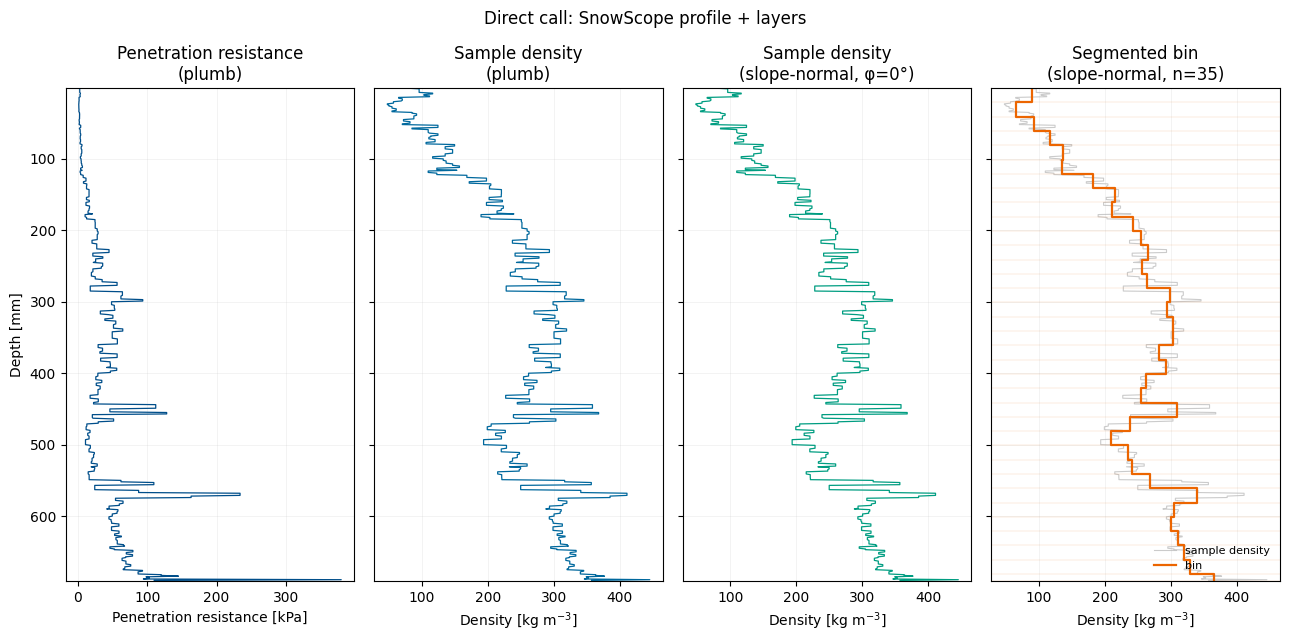

In [15]:
layers, _ = scope.extract_layers(method="bin", layer_thickness_mm=20.0)
print(
    "n layers:",
    len(layers),
    "| first:",
    "rho=%.0f h=%.1f" % (layers[0].rho, layers[0].h),
)
fig = plot_force_penetration_layers(
    scope_profile,
    layers,
    layer_label="bin",
    title="Direct call: SnowScope profile + layers",
    show=False,
)

# Overlay: all three sources

`demo/data/` now holds a third, co-located profile: the SnowPilot **CAAML** (`.xml`) export of the same Weissfluhjoch pit (its notes reference the same SnowScope runs 669-679). The three parsers report layers on different vertical grids - the probes emit fixed `bin`/`gradient` slabs, SnowPilot emits hand-hardness/observation layers - but all are ordered surface -> ground with slope-normal `Layer.h`.

We overlay the reconstructed density-vs-depth staircases on one axis, each anchored at the snow surface (depth 0, increasing downward), so the layering from the three instruments can be compared directly despite differing total snow heights.

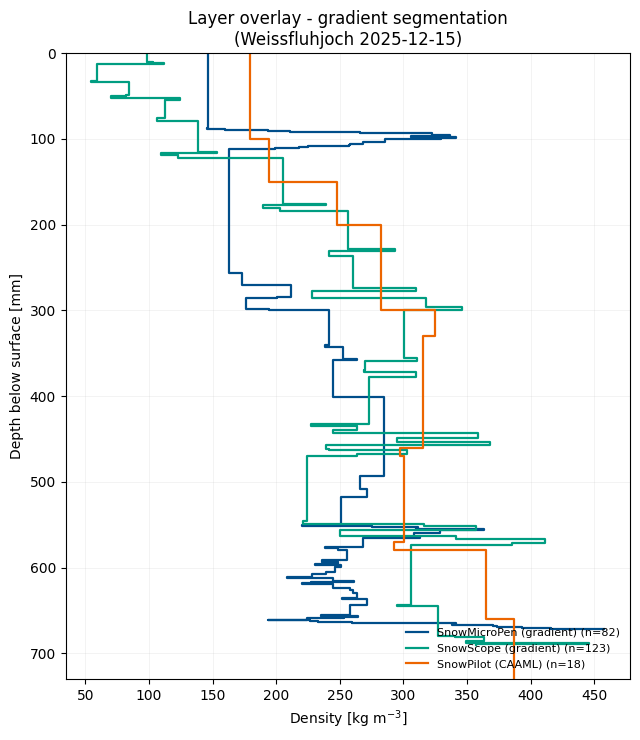

In [16]:
import matplotlib.pyplot as plt

XML = DATA / "Profile-35ace732-eb53-4f85-aa48-4a964c0d6877.xml"
pilot = SnowPilotParser(str(XML))

# Layers surface -> ground from each source (gradient).
smp_layers, _ = smp.extract_layers(method="gradient")
scope_layers, _ = scope.extract_layers(method="gradient")
pilot_layers, _ = pilot.extract_layers()


def staircase(layers):
    """Density-vs-depth staircase anchored at the surface (depth 0, downward)."""
    import numpy as np

    h = np.array([layer.h for layer in layers], float)
    rho = np.repeat([layer.rho for layer in layers], 2)
    bottoms = np.cumsum(h)
    tops = np.concatenate(([0.0], bottoms[:-1]))
    depth = np.empty(rho.size)
    depth[0::2] = tops
    depth[1::2] = bottoms
    return rho, depth


sources = [
    ("SnowMicroPen (gradient)", smp_layers, "#004E8A"),
    ("SnowScope (gradient)", scope_layers, "#009D81"),
    ("SnowPilot (CAAML)", pilot_layers, "#EC6500"),
]

fig, ax = plt.subplots(figsize=(6.5, 7.5))
max_depth = 0.0
for label, layers, color in sources:
    rho, depth = staircase(layers)
    max_depth = max(max_depth, float(depth[-1]))
    ax.plot(rho, depth, color=color, lw=1.6, label=f"{label} (n={len(layers)})")

ax.set_xlabel("Density [kg m$^{-3}$]")
ax.set_ylabel("Depth below surface [mm]")
ax.set_title("Layer overlay - gradient segmentation\n(Weissfluhjoch 2025-12-15)")
ax.set_ylim(max_depth, 0.0)
ax.grid(True, alpha=0.25, lw=0.4)
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

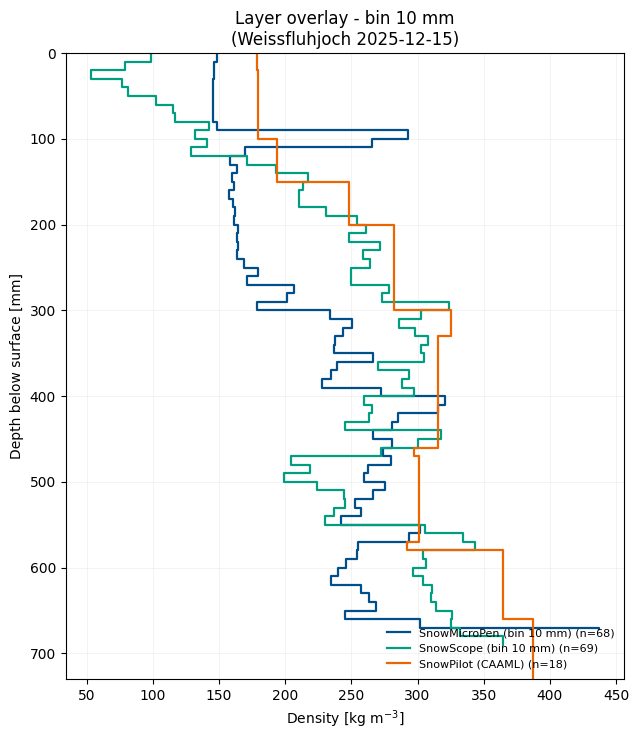

In [17]:
import matplotlib.pyplot as plt

smp_layers, _ = smp.extract_layers(method="bin", layer_thickness_mm=10)
scope_layers, _ = scope.extract_layers(method="bin", layer_thickness_mm=10)

XML = DATA / "Profile-35ace732-eb53-4f85-aa48-4a964c0d6877.xml"
pilot = SnowPilotParser(str(XML))
pilot_layers, _ = pilot.extract_layers()


def staircase(layers):
    """Density-vs-depth staircase anchored at the surface (depth 0, downward)."""
    import numpy as np

    h = np.array([layer.h for layer in layers], float)
    rho = np.repeat([layer.rho for layer in layers], 2)
    bottoms = np.cumsum(h)
    tops = np.concatenate(([0.0], bottoms[:-1]))
    depth = np.empty(rho.size)
    depth[0::2] = tops
    depth[1::2] = bottoms
    return rho, depth


sources = [
    ("SnowMicroPen (bin 10 mm)", smp_layers, "#004E8A"),
    ("SnowScope (bin 10 mm)", scope_layers, "#009D81"),
    ("SnowPilot (CAAML)", pilot_layers, "#EC6500"),
]

fig, ax = plt.subplots(figsize=(6.5, 7.5))
max_depth = 0.0
for label, layers, color in sources:
    rho, depth = staircase(layers)
    max_depth = max(max_depth, float(depth[-1]))
    ax.plot(rho, depth, color=color, lw=1.6, label=f"{label} (n={len(layers)})")

ax.set_xlabel("Density [kg m$^{-3}$]")
ax.set_ylabel("Depth below surface [mm]")
ax.set_title("Layer overlay - bin 10 mm\n(Weissfluhjoch 2025-12-15)")
ax.set_ylim(max_depth, 0.0)
ax.grid(True, alpha=0.25, lw=0.4)
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()